# Trabalho Prático 01 - Classificação KNN (Scikit-learn)

**Disciplina:** GCC 128 - Inteligência Artificial  
**Professor:** Ahmed Ali Abdalla Esmin    
**Alunos:** Daniel de Jesus Moreira, João Guilherme Santos Ribeiro

---

## Introdução

Nesta etapa, implementamos o classificador KNN utilizando a biblioteca **Scikit-learn**, que oferece uma implementação otimizada e consolidada do algoritmo. 

O objetivo é comparar esta abordagem com a implementação manual (hardcore), analisando:

- Acurácia
- Precisão
- Revocação
- Matriz de confusão
- Tempo de execução

## Metodologia

Neste notebook, seguimos os seguintes passos:

1. Carregamento da base Iris
2. Embaralhamento dos dados e divisão em treino (80%) e teste (20%)
3. Treinamento do `KNeighborsClassifier` para $k \in \{1, 3, 5, 7\}$
4. Cálculo das métricas de avaliação para cada valor de $k$
5. Plotagem da matriz de confusão

Essa implementação serve como referência para avaliar o desempenho de uma solução pronta de mercado em comparação ao algoritmo desenvolvido do zero.

Sklearn k=1 | Acurácia: 0.9667 | Precisão: 0.9704 | Revocação: 0.9667
Tempo de execução: 0.0060 segundos


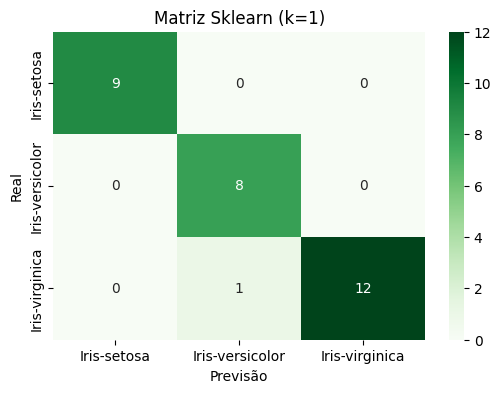

Sklearn k=3 | Acurácia: 0.9667 | Precisão: 0.9704 | Revocação: 0.9667
Tempo de execução: 0.0077 segundos


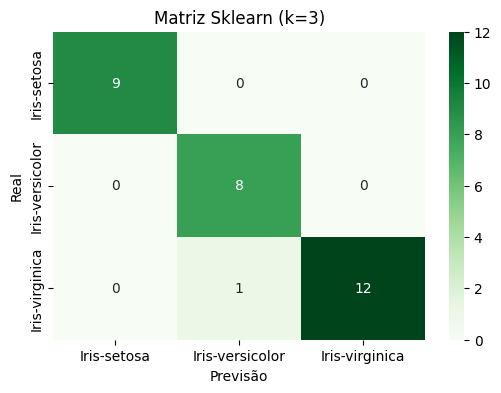

Sklearn k=5 | Acurácia: 0.9667 | Precisão: 0.9704 | Revocação: 0.9667
Tempo de execução: 0.0020 segundos


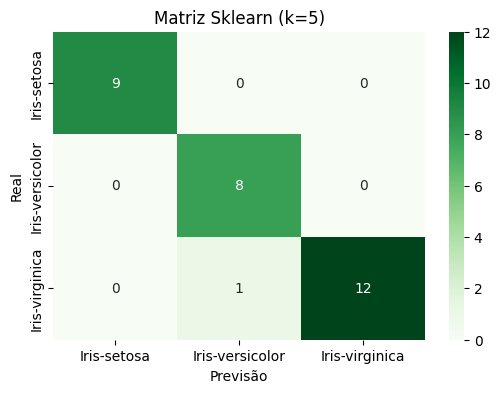

Sklearn k=7 | Acurácia: 0.9333 | Precisão: 0.9467 | Revocação: 0.9333
Tempo de execução: 0.0030 segundos


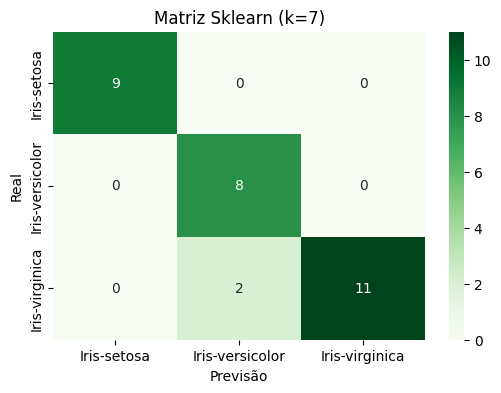

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import time

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
colunas = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df = pd.read_csv(url, names=colunas)

df_embaralhado = df.sample(frac=1, random_state=73).reset_index(drop=True)

tamanho_treino = int(0.8 * len(df_embaralhado))

df_treino = df_embaralhado.iloc[:tamanho_treino]
df_teste = df_embaralhado.iloc[tamanho_treino:]

X_treino = df_treino.drop('species', axis=1).values
y_treino = df_treino['species'].values

X_teste = df_teste.drop('species', axis=1).values
y_teste = df_teste['species'].values

classes = np.unique(y_teste)
valores_k = [1, 3, 5, 7]

for k in valores_k:
    inicio_sklearn = time.time()
    modelo_sklearn = KNeighborsClassifier(n_neighbors=k)
    modelo_sklearn.fit(X_treino, y_treino)
    previsoes_sklearn = modelo_sklearn.predict(X_teste)
    fim_sklearn = time.time()
    tempo_execucao = fim_sklearn - inicio_sklearn
    
    acuracia = accuracy_score(y_teste, previsoes_sklearn)
    precisao = precision_score(y_teste, previsoes_sklearn, average='weighted')
    revocacao = recall_score(y_teste, previsoes_sklearn, average='weighted')
    
    print(f"Sklearn k={k} | Acurácia: {acuracia:.4f} | Precisão: {precisao:.4f} | Revocação: {revocacao:.4f}")
    print(f"Tempo de execução: {tempo_execucao:.4f} segundos")
    
    matriz_sklearn = confusion_matrix(y_teste, previsoes_sklearn)
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(matriz_sklearn, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes)
    plt.title(f'Matriz Sklearn (k={k})')
    plt.xlabel('Previsão')
    plt.ylabel('Real')
    plt.show()

## Análise dos Resultados

Com os resultados obtidos para cada valor de $k$, podemos comparar:

- O melhor desempenho do KNN com biblioteca
- A estabilidade das métricas entre diferentes valores de vizinhos
- O tempo de execução em relação à implementação manual

### Conclusão

Com base nas métricas e matrizes de confusão geradas, a implementação com Scikit-learn manteve desempenho de classificação muito semelhante à implementação hardcore para $k=1,3,5$ e apresentou leve queda para $k=7$. Em geral, a abordagem com biblioteca se mostrou consistente e eficiente para o problema proposto.